# 01 — Exploratory Data Analysis (EDA)
## CIC-MalDroid 2020 · Static Feature Dataset

**Mục tiêu:**
- Load dataset lớn (50K+ features) một cách tối ưu; auto-convert sang Parquet để load nhanh lần sau
- Khám phá phân phối nhãn (5 lớp: Adware, Banking, SMS, Riskware, Benign)
- Phân tích tần suất permissions nhạy cảm giữa malware và benign
- Xác định API calls thường bị lạm dụng bởi mã độc
- Đánh giá tương quan giữa các đặc trưng quan trọng

## 1. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

# ── Đường dẫn ──────────────────────────────────────────────────────────────
BASE_DIR      = Path(r'H:\tdc_window\Local_Workspace\01_UIT_IT2029_Malware\code\exp-maldroid2020')
CSV_PATH      = BASE_DIR / 'csv' / 'feature_vectors_static.csv'
PARQUET_PATH  = BASE_DIR / 'csv' / 'feature_vectors_static.parquet'
# File dynamic chứa cột 'Class' (cùng 11,598 APK, cùng thứ tự với static CSV)
LABEL_CSV     = BASE_DIR / 'csv' / 'other csvs' / 'feature_vectors_syscalls_frequency_5_Cat.csv'
FIG_DIR       = BASE_DIR / 'notebooks' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Mapping số → tên lớp (theo CICMalDroid 2020 paper & UNB dataset page)
CLASS_MAP = {1: 'Adware', 2: 'Banking', 3: 'SMS', 4: 'Riskware', 5: 'Benign'}
# int hoặc float key đều cover
CLASS_MAP.update({float(k): v for k, v in CLASS_MAP.items()})

print(f'CSV    : {CSV_PATH}')
print(f'Parquet: {PARQUET_PATH}')
print(f'Labels : {LABEL_CSV}')
print(f'Figures: {FIG_DIR}')

CSV    : H:\tdc_window\Local_Workspace\01_UIT_IT2029_Malware\code\exp-maldroid2020\csv\feature_vectors_static.csv
Parquet: H:\tdc_window\Local_Workspace\01_UIT_IT2029_Malware\code\exp-maldroid2020\csv\feature_vectors_static.parquet
Labels : H:\tdc_window\Local_Workspace\01_UIT_IT2029_Malware\code\exp-maldroid2020\csv\other csvs\feature_vectors_syscalls_frequency_5_Cat.csv
Figures: H:\tdc_window\Local_Workspace\01_UIT_IT2029_Malware\code\exp-maldroid2020\notebooks\figures


## 2. Load dữ liệu

**Chiến lược:** Lần đầu đọc từ CSV → lưu sang Parquet (nhanh hơn ~5-10x, nhỏ hơn đáng kể).  
Các lần sau load Parquet trực tiếp.

In [2]:
def load_data(parquet_path: Path, csv_path: Path) -> pd.DataFrame:
    """Load từ Parquet nếu có, không thì đọc CSV → tạo Parquet."""
    if parquet_path.exists():
        print(f'[INFO] Loading from Parquet: {parquet_path.name}')
        return pd.read_parquet(parquet_path, engine='pyarrow')

    print('[INFO] Parquet chưa có. Đọc từ CSV (có thể mất 1–3 phút)...')
    chunks = []
    chunk_size = 2000
    for i, chunk in enumerate(pd.read_csv(csv_path, chunksize=chunk_size, low_memory=False)):
        chunks.append(chunk)
        print(f'  Chunk {i+1} ({(i+1)*chunk_size} rows)', end='\r')
    df = pd.concat(chunks, ignore_index=True)

    print(f'\n[INFO] Lưu Parquet...')
    df.to_parquet(parquet_path, engine='pyarrow', compression='snappy', index=False)
    print(f'[OK]   Đã lưu → {parquet_path.name}')
    return df

df = load_data(PARQUET_PATH, CSV_PATH)
print(f'\nShape (static features): {df.shape}')
print(f'Memory: {df.memory_usage(deep=True).sum() / 1e9:.2f} GB')

# ── Gán nhãn từ dynamic CSV ─────────────────────────────────────────────────
# File static KHÔNG có cột nhãn; nhãn nằm ở dynamic CSV cùng thứ tự row
print('\n[INFO] Đọc nhãn từ dynamic CSV...')
label_series = pd.read_csv(LABEL_CSV, usecols=['Class'])['Class']
df['Class'] = label_series.map(CLASS_MAP).values  # int/float → tên lớp

# Kiểm tra nhanh
missing_labels = df['Class'].isna().sum()
print(f'[OK]   Gán xong. Missing labels: {missing_labels}')
print(f'       Unique classes: {sorted(df["Class"].dropna().unique().tolist())}')
print(f'       Class distribution:\n{df["Class"].value_counts().to_string()}')

[INFO] Loading from Parquet: feature_vectors_static.parquet

Shape (static features): (11598, 50621)
Memory: 4.70 GB

[INFO] Đọc nhãn từ dynamic CSV...
[OK]   Gán xong. Missing labels: 0
       Unique classes: ['Adware', 'Banking', 'Benign', 'Riskware', 'SMS']
       Class distribution:
Class
SMS         3904
Riskware    2546
Banking     2100
Benign      1795
Adware      1253


## 3. Thống kê tổng quan schema

In [3]:
print('=== 5 cột đầu ===')
print(df.columns[:5].tolist())
print('\n=== 5 cột cuối ===')
print(df.columns[-5:].tolist())
print(f'\nTổng số cột : {df.shape[1]:,}')
print(f'Số hàng (APK): {df.shape[0]:,}')

=== 5 cột đầu ===
['Unnamed: 0', "' a:targetActivity+AD0-'com.mplus.lib.ui.main.MainActivity' tools:targetApi+AD0-'25'+AD4AXA-n            +ADw-intent+AC0-filter+AD4AXA-n                +ADw-action a:name+AD0-'android.intent.action.MAIN'/+AD4AXA-n                +ADw-category a:name+AD0-'android.intent.category.LAUNCHER'/+AD4AXA-n            +ADw-/intent+AC0-filter+AD4AXA-n        +ADw-/activity+AC0-alias+AD4AXA-n", "Can't find launcher app through android.intent.category.HOME category and android.intent.action.MAIN action", '+ACI-More than one BroadcastReceiver that handles android.intent.action.MEDIA+AF8-BUTTON was found', "Please replace '+AFw-xe3+AFw-x80+AFw-x90+AFw-xe5+AFw-xba+AFw-x94+AFw-xe7+AFw-x94+AFw-xa8+AFw-xe5+AFw-x8c+AFw-x85+AFw-xe5+AFw-x90+AFw-x8d+AFw-xe3+AFw-x80+AFw-x91.intent.action.COCKROACH' with application's packageName for UmengService in AndroidManifest+ACE-"]

=== 5 cột cuối ===
['Lcom/medibang/android/paint/tablet/model/information/Information; => setIntenturl =>

In [4]:
# Cột nhãn đã được gán khi load (từ dynamic CSV)
LABEL_COL = 'Class'
print(f'Cột nhãn: "{LABEL_COL}"')
print(f'Giá trị unique ({df[LABEL_COL].nunique()} lớp): {sorted(df[LABEL_COL].dropna().unique().tolist())}')

y = df[LABEL_COL].copy()
X = df.drop(columns=[LABEL_COL])
print(f'\nFeature matrix (chỉ features): {X.shape}')
print(f'Label series                 : {y.shape}')

# fillna(0): NaN trong static features = feature vắng mặt → gán 0 là hợp lý
# vì đây là binary presence/absence vector (0/1/NaN)
X_filled = X.select_dtypes(include='number').fillna(0)
print(f'\nSau fillna(0) — numeric features: {X_filled.shape}')

Cột nhãn: "Class"
Giá trị unique (5 lớp): ['Adware', 'Banking', 'Benign', 'Riskware', 'SMS']

Feature matrix (chỉ features): (11598, 50621)
Label series                 : (11598,)

Sau fillna(0) — numeric features: (11598, 50606)


In [5]:
# Kiểu dữ liệu các cột
dtype_counts = X.dtypes.value_counts()
print('=== Dtype distribution ===')
print(dtype_counts)

=== Dtype distribution ===
float64    50605
str           10
object         5
int64          1
Name: count, dtype: int64


## 4. Phân phối nhãn (Label Distribution)

In [6]:
label_counts = y.value_counts().sort_values(ascending=False)
print('=== Label Distribution ===')
for lbl, cnt in label_counts.items():
    pct = cnt / len(y) * 100
    print(f'  {str(lbl):<15} {cnt:>6,}  ({pct:.1f}%)')

# Mức độ mất cân bằng
imbalance_ratio = label_counts.max() / label_counts.min()
print(f'\nImbalance ratio (max/min): {imbalance_ratio:.1f}x')

=== Label Distribution ===
  SMS              3,904  (33.7%)
  Riskware         2,546  (22.0%)
  Banking          2,100  (18.1%)
  Benign           1,795  (15.5%)
  Adware           1,253  (10.8%)

Imbalance ratio (max/min): 3.1x


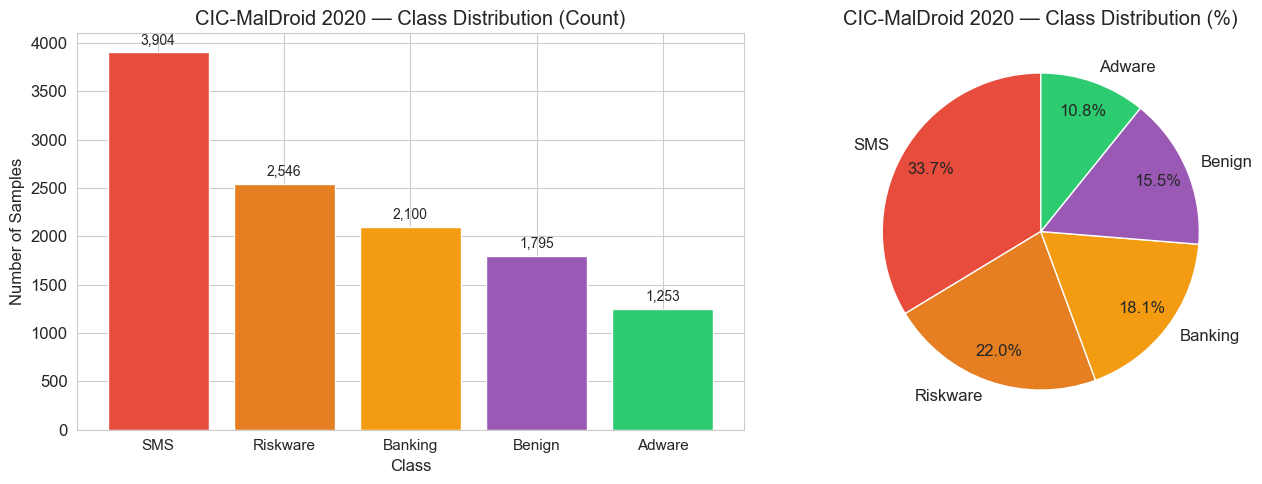

Saved: 01_label_distribution.png


In [7]:
# Màu sắc
COLORS = ['#e74c3c', '#e67e22', '#f39c12', '#9b59b6', '#2ecc71']
labels_ordered = label_counts.index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
bars = axes[0].bar(range(len(label_counts)), label_counts.values, color=COLORS[:len(label_counts)])
axes[0].set_xticks(range(len(label_counts)))
axes[0].set_xticklabels([str(l) for l in labels_ordered], fontsize=11)
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Number of Samples')
axes[0].set_title('CIC-MalDroid 2020 — Class Distribution (Count)')
for bar, val in zip(bars, label_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,}', ha='center', va='bottom', fontsize=10)

# Pie chart
axes[1].pie(label_counts.values,
            labels=[str(l) for l in labels_ordered],
            autopct='%1.1f%%',
            colors=COLORS[:len(label_counts)],
            startangle=90,
            pctdistance=0.8)
axes[1].set_title('CIC-MalDroid 2020 — Class Distribution (%)')

plt.tight_layout()
plt.savefig(FIG_DIR / '01_label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 01_label_distribution.png')

## 5. Phân tích giá trị thiếu (NaN / Sparsity)

In [8]:
# Chỉ tính NaN trên cột numeric (cột object/string bỏ qua)
X_num_only  = X.select_dtypes(include='number')
X_obj_only  = X.select_dtypes(include='object')
total_cells = X_num_only.shape[0] * X_num_only.shape[1]
nan_count   = X_num_only.isna().sum().sum()
nan_pct     = nan_count / total_cells * 100 if total_cells > 0 else 0

print(f'=== Sparsity / NaN Analysis (cột numeric) ===')
print(f'Cột numeric         : {X_num_only.shape[1]:,}')
print(f'Cột object/string   : {X_obj_only.shape[1]:,}  (bỏ qua trong NaN analysis)')
print(f'Tổng số ô (numeric) : {total_cells:,}')
print(f'Ô NaN               : {nan_count:,}  ({nan_pct:.2f}%)')
print(f'Ô không NaN         : {total_cells - nan_count:,}  ({100-nan_pct:.2f}%)')

# NaN theo cột numeric
nan_per_col = X_num_only.isna().mean() * 100
print(f'\nFeatures với 0% NaN      : {(nan_per_col == 0).sum():,}')
print(f'Features với >90% NaN     : {(nan_per_col > 90).sum():,}')
print(f'Features với 100% NaN     : {(nan_per_col == 100).sum():,}  ← nên xóa')

=== Sparsity / NaN Analysis (cột numeric) ===
Cột numeric         : 50,606
Cột object/string   : 15  (bỏ qua trong NaN analysis)
Tổng số ô (numeric) : 586,928,388
Ô NaN               : 585,460,446  (99.75%)
Ô không NaN         : 1,467,942  (0.25%)

Features với 0% NaN      : 2
Features với >90% NaN     : 50,379
Features với 100% NaN     : 18,931  ← nên xóa


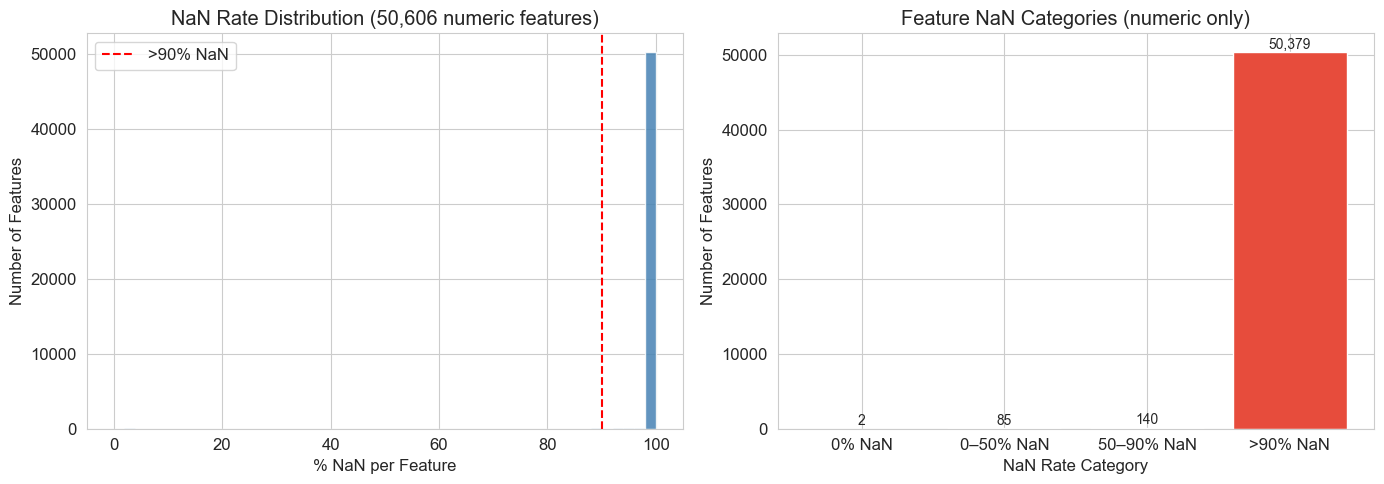

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram tỷ lệ NaN theo feature
axes[0].hist(nan_per_col, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(90, color='red', linestyle='--', linewidth=1.5, label='>90% NaN')
axes[0].set_xlabel('% NaN per Feature')
axes[0].set_ylabel('Number of Features')
axes[0].set_title(f'NaN Rate Distribution ({X_num_only.shape[1]:,} numeric features)')
axes[0].legend()

# Tóm tắt dạng bar
buckets = {
    '0% NaN':    (nan_per_col == 0).sum(),
    '0–50% NaN': ((nan_per_col > 0) & (nan_per_col <= 50)).sum(),
    '50–90% NaN':((nan_per_col > 50) & (nan_per_col <= 90)).sum(),
    '>90% NaN':  (nan_per_col > 90).sum(),
}
axes[1].bar(buckets.keys(), buckets.values(), color=['#2ecc71','#f39c12','#e67e22','#e74c3c'])
axes[1].set_xlabel('NaN Rate Category')
axes[1].set_ylabel('Number of Features')
axes[1].set_title('Feature NaN Categories (numeric only)')
for i, (k, v) in enumerate(buckets.items()):
    axes[1].text(i, v + 50, f'{v:,}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig(FIG_DIR / '02_nan_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Gom nhóm đặc trưng theo loại tĩnh

Với CIC-MalDroid 2020, tên cột mang thông tin về loại đặc trưng.
Ta phát hiện nhóm dựa trên pattern tên cột.

In [10]:
def detect_feature_group(col: str) -> str:
    """Phân loại feature dựa trên pattern tên cột."""
    cl = col.lower()
    if 'permission' in cl or cl.isupper():          return 'Permissions'
    if 'intent' in cl:                               return 'Intents'
    if cl.startswith('ljava') or 'java' in cl:       return 'Java API Calls'
    if 'android.' in cl and 'intent' not in cl:      return 'Android API Calls'
    if 'service' in cl:                              return 'Services'
    if 'receiver' in cl:                             return 'Receivers'
    if 'activity' in cl or 'activities' in cl:       return 'Activities'
    if 'package' in cl or 'provider' in cl:          return 'Packages/Providers'
    if 'file' in cl:                                 return 'Files'
    return 'Others'

feature_groups = X.columns.to_series().apply(detect_feature_group)
group_counts   = feature_groups.value_counts()

print('=== Feature Groups ===')
for grp, cnt in group_counts.items():
    print(f'  {grp:<25} {cnt:>8,}  ({cnt/len(X.columns)*100:.1f}%)')

=== Feature Groups ===
  Intents                     22,576  (44.6%)
  Others                      12,086  (23.9%)
  Receivers                    4,986  (9.8%)
  Permissions                  3,733  (7.4%)
  Android API Calls            3,331  (6.6%)
  Activities                   1,923  (3.8%)
  Services                     1,378  (2.7%)
  Packages/Providers             480  (0.9%)
  Files                          114  (0.2%)
  Java API Calls                  14  (0.0%)


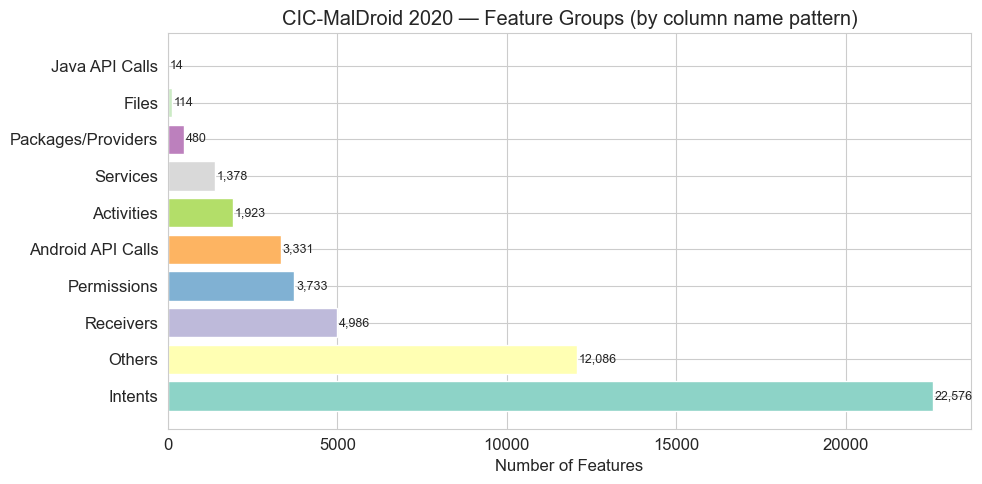

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
colors_grp = plt.cm.Set3(np.linspace(0, 1, len(group_counts)))
bars = ax.barh(group_counts.index, group_counts.values, color=colors_grp)
ax.set_xlabel('Number of Features')
ax.set_title('CIC-MalDroid 2020 — Feature Groups (by column name pattern)')
for bar, val in zip(bars, group_counts.values):
    ax.text(val + 50, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / '03_feature_groups.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Tần suất Permissions nhạy cảm: Malware vs Benign

In [12]:
# Lấy tên cột permissions (tên viết hoa thường là permissions trong Android)
perm_cols = [c for c in X.columns
             if ('permission' in c.lower() or (c.isupper() and '_' in c))
             and len(c) > 3]
print(f'Số cột Permissions tìm thấy: {len(perm_cols)}')
print('Ví dụ:', perm_cols[:10])

Số cột Permissions tìm thấy: 3944
Ví dụ: ["' declares com.google.android.c2dm.intent.REGISTER without permission'", "+ACI-'+ADw-receiver android:name+AD0AIgAi-com.alooma.android.mpmetrics.GCMReceiver+ACIAIgBc-n          android:permission+AD0AIgAi-com.google.android.c2dm.permission.SEND+ACIAIg- +AD4AXA-n    +ADw-intent+AC0-filter+AD4AXA-n       +ADw-action android:name+AD0AIgAi-com.google.android.c2dm.intent.RECEIVE+ACIAIg- /+AD4AXA-n       +ADw-action android:name+AD0AIgAi-com.google.android.c2dm.intent.REGISTRATION+ACIAIg- /+AD4AXA-n       +ADw-category android:name+AD0AIgAi-'+ACI-", "+ACI-'+ADw-receiver android:name+AD0AIgAi-com.mixpanel.android.mpmetrics.GCMReceiver+ACIAIgBc-n          android:permission+AD0AIgAi-com.google.android.c2dm.permission.SEND+ACIAIg- +AD4AXA-n    +ADw-intent+AC0-filter+AD4AXA-n       +ADw-action android:name+AD0AIgAi-com.google.android.c2dm.intent.RECEIVE+ACIAIg- /+AD4AXA-n       +ADw-action android:name+AD0AIgAi-com.google.android.c2dm.intent.REGISTRATIO

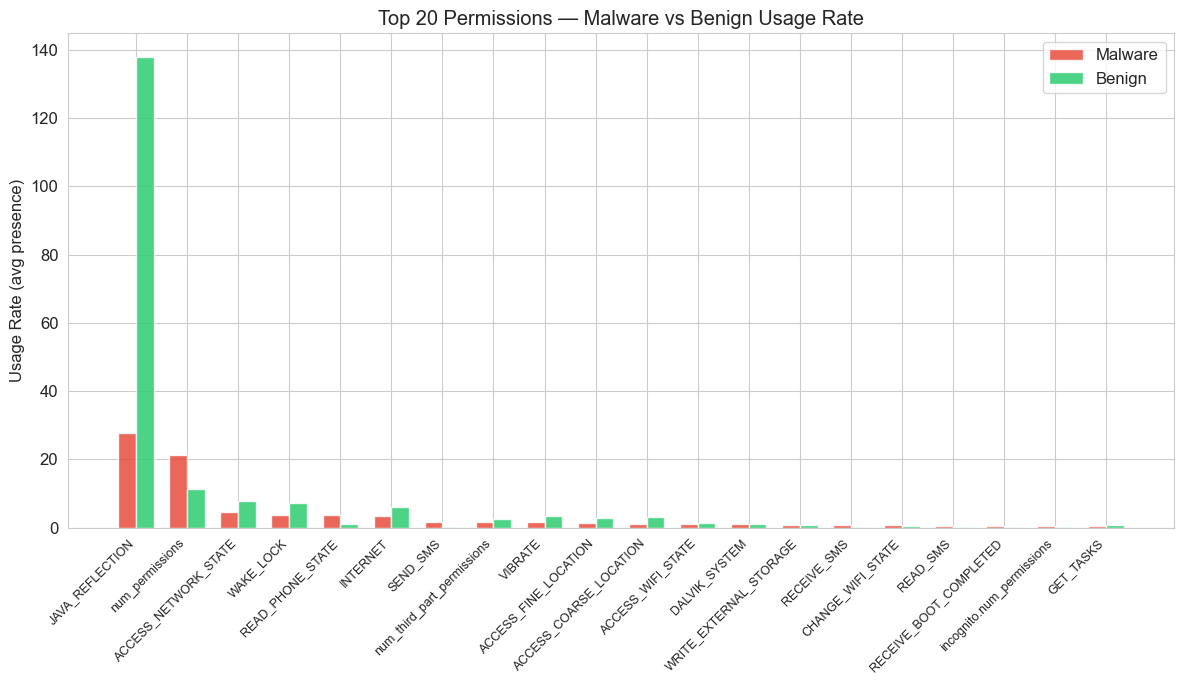

In [13]:
if len(perm_cols) > 0:
    X_perm = X[perm_cols].fillna(0)

    # Tách malware và benign (dùng giá trị cột nhãn thực tế)
    benign_labels = [v for v in y.unique() if 'benign' in str(v).lower() or str(v) == '5']
    is_benign = y.isin(benign_labels)

    perm_mal = X_perm[~is_benign].mean().sort_values(ascending=False)
    perm_ben = X_perm[is_benign].mean().sort_values(ascending=False)

    # Top 20 permissions được dùng nhiều nhất bởi malware
    top_mal_perms = perm_mal.head(20).index.tolist()

    df_perm_plot = pd.DataFrame({
        'Malware': perm_mal[top_mal_perms].values,
        'Benign':  perm_ben.reindex(top_mal_perms).fillna(0).values,
    }, index=[c.replace('android.permission.', '').replace('android.', '') for c in top_mal_perms])

    fig, ax = plt.subplots(figsize=(12, 7))
    x_pos = np.arange(len(df_perm_plot))
    width = 0.35
    bars1 = ax.bar(x_pos - width/2, df_perm_plot['Malware'], width, label='Malware', color='#e74c3c', alpha=0.85)
    bars2 = ax.bar(x_pos + width/2, df_perm_plot['Benign'],  width, label='Benign',  color='#2ecc71', alpha=0.85)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(df_perm_plot.index, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('Usage Rate (avg presence)')
    ax.set_title('Top 20 Permissions — Malware vs Benign Usage Rate')
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / '04_permissions_malware_vs_benign.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('[WARN] Không tìm thấy cột permissions. Kiểm tra lại tên cột.')
    print('Gợi ý: Điều chỉnh hàm detect_feature_group() theo tên cột thực tế.')

## 8. Top API Calls bị lạm dụng bởi mã độc

In [14]:
api_cols = [c for c in X.columns
            if ('java' in c.lower() or 'android.' in c.lower() or c.startswith('L'))
            and 'intent' not in c.lower()
            and 'permission' not in c.lower()]
print(f'Số cột API Calls tìm thấy: {len(api_cols)}')
print('Ví dụ:', api_cols[:10])

Số cột API Calls tìm thấy: 8681
Ví dụ: ['JAVA+AF8-REFLECTION', 'Java', 'LANalyzer', 'LAST', 'LExtensions/CRunAndroid+ACQ-3', 'LExtensions/CRunAndroid', 'LExtensions/CRunAndroid.1', 'LExtensions/CRunAndroid.2', 'LExtensions/CRunAndroid.3', 'LExtensions/CRunAndroid.4']


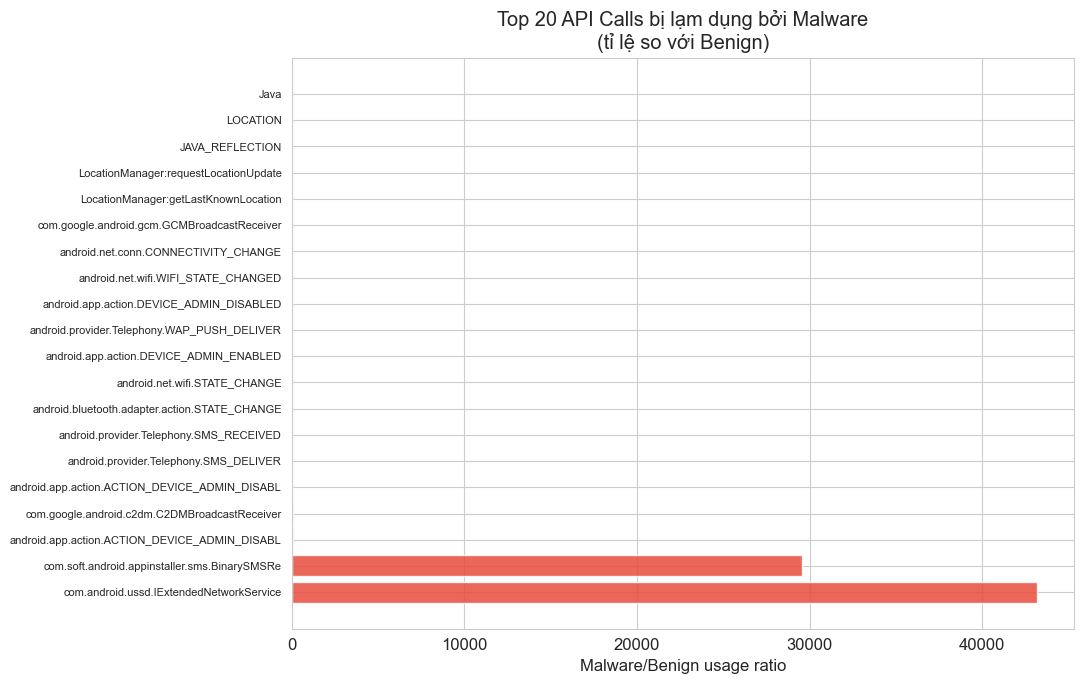

In [15]:
if len(api_cols) > 0 and 'is_benign' in dir():
    X_api = X[api_cols].fillna(0)
    api_mal = X_api[~is_benign].mean()
    api_ben = X_api[is_benign].mean()

    # Tỉ lệ malware/benign: API nào malware dùng nhiều hơn benign nhiều nhất
    api_ratio = (api_mal / (api_ben + 1e-6)).sort_values(ascending=False)
    top_abused = api_ratio[api_mal > 0.02].head(20)  # Chỉ lấy API có usage > 2% trong malware

    if len(top_abused) > 0:
        short_names = [c.replace('Ljava/', '').replace('Landroid/', '').replace(';->', '.')[:45]
                       for c in top_abused.index]
        fig, ax = plt.subplots(figsize=(11, 7))
        bars = ax.barh(range(len(top_abused)), top_abused.values, color='#e74c3c', alpha=0.85)
        ax.set_yticks(range(len(top_abused)))
        ax.set_yticklabels(short_names[::-1] if False else short_names, fontsize=8)
        ax.set_xlabel('Malware/Benign usage ratio')
        ax.set_title('Top 20 API Calls bị lạm dụng bởi Malware\n(tỉ lệ so với Benign)')
        plt.tight_layout()
        plt.savefig(FIG_DIR / '05_api_abuse.png', dpi=150, bbox_inches='tight')
        plt.show()
    else:
        print('[INFO] Không đủ cột API để vẽ abuse chart. Thử điều chỉnh ngưỡng 0.02.')
else:
    print('[WARN] Không tìm thấy cột API hoặc chưa phân tách malware/benign.')

## 9. Correlation Heatmap (Top 30 features theo variance)

In [16]:
# Với 50K+ features, không thể vẽ correlation toàn bộ
# Chỉ lấy cột numeric, sau đó tính variance và lấy top 30
X_numeric = X.select_dtypes(include='number').fillna(0)
print(f'Cột numeric: {X_numeric.shape[1]:,} / {X.shape[1]:,} tổng')
variances  = X_numeric.var(numeric_only=True)
top30_cols = variances.nlargest(30).index.tolist()
print(f'Top 30 features theo variance:')
print([c[:50] for c in top30_cols])

Cột numeric: 50,606 / 50,621 tổng
Top 30 features theo variance:
['version_code', 'incognito.version_code', 'ANDROID', 'Unnamed: 0', 'SUPPORT', 'OS', 'VIEW', 'num_files', 'CONTENT', 'ascii_obfuscation', 'PNG', 'WIDGET', 'UTIL', 'GRAPHICS', 'data', 'emulator', 'APP', 'reflection', 'TEXT', 'native_code', 'Standard', 'JAVA_REFLECTION', 'MEDIA', 'DATABASE', 'NET', 'ASCII', 'Java', 'WEBKIT', 'MPEG', 'File:exists']


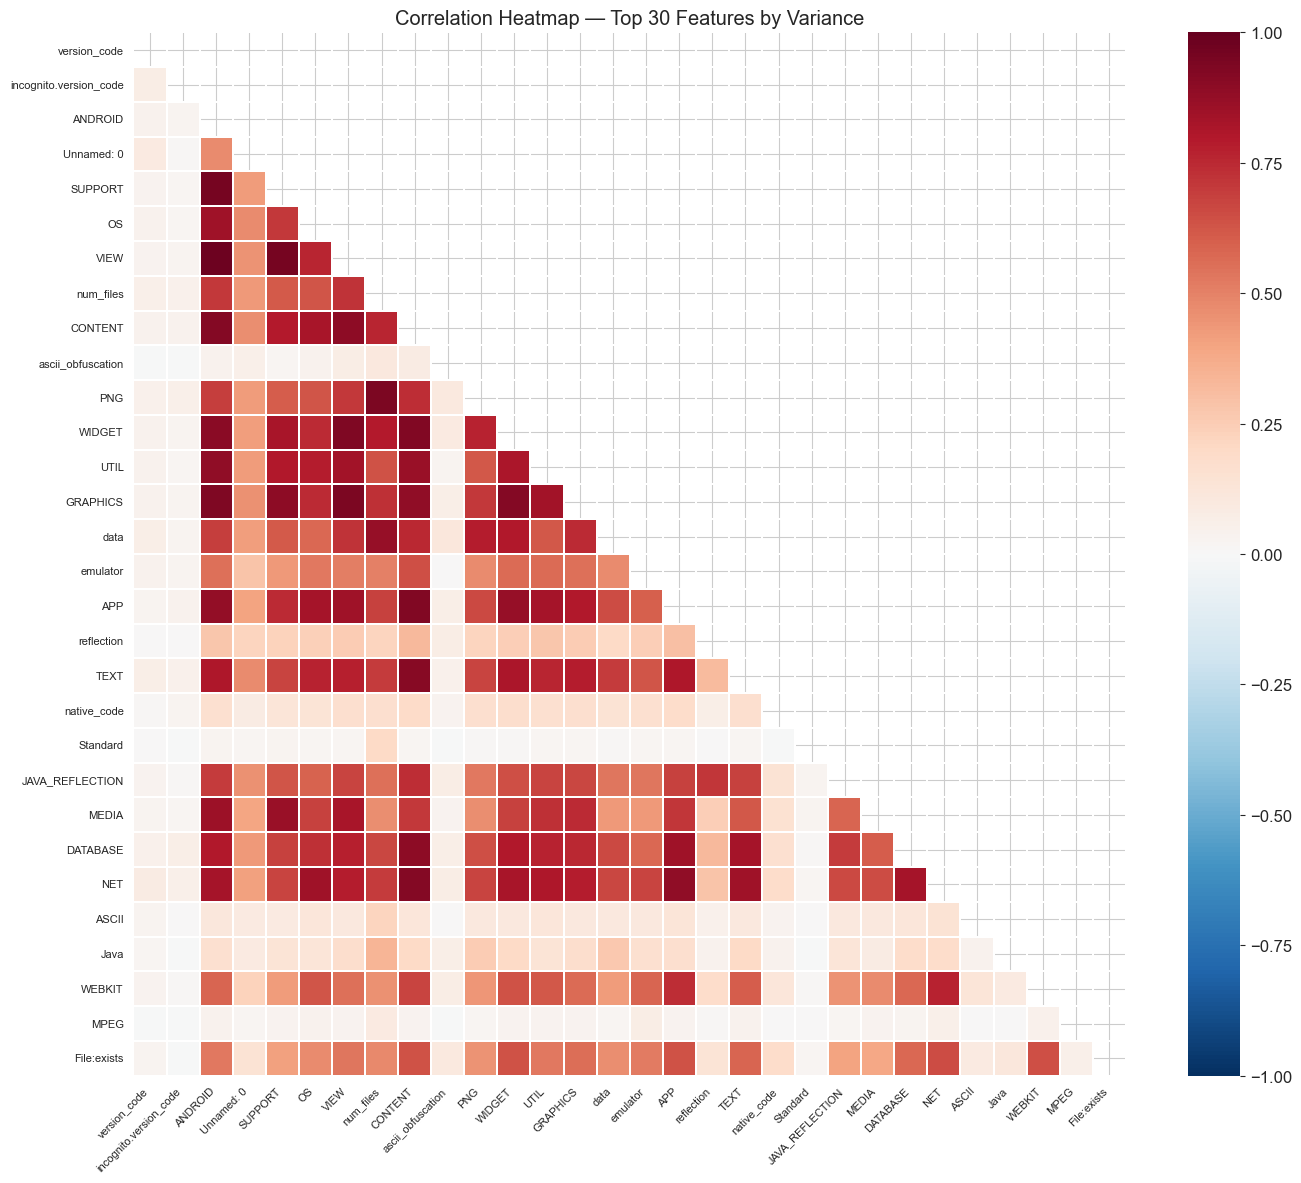

In [17]:
corr_matrix = X_numeric[top30_cols].corr()
short_labels = [c.replace('android.permission.', '').replace('android.', '')[:30]
                for c in top30_cols]

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=False,
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    xticklabels=short_labels,
    yticklabels=short_labels,
    ax=ax,
    linewidths=0.3,
)
ax.set_title('Correlation Heatmap — Top 30 Features by Variance')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / '06_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Tóm tắt EDA

In [18]:
print('=' * 55)
print('  EDA Summary — CIC-MalDroid 2020 Static Features')
print('=' * 55)
print(f'  Số APK (samples)      : {df.shape[0]:,}')
print(f'  Số đặc trưng tĩnh     : {X.shape[1]:,}')
print(f'  Số nhãn lớp           : {y.nunique()} lớp')
print(f'  Tỉ lệ NaN toàn bộ     : {nan_pct:.1f}%  (sparse data)')
print(f'  Features 100% NaN     : {(nan_per_col == 100).sum():,}  (nên drop)')
print(f'  Imbalance ratio       : {imbalance_ratio:.1f}x')
print('  Nhóm features chính   :', ', '.join(group_counts.head(4).index.tolist()))
print('=' * 55)
print()
print('Bước tiếp theo → 02_pipeline.ipynb')
print('  RRFS + Train RF/SVM/KNN/NB/MLP + Stratified 5-Fold CV')

  EDA Summary — CIC-MalDroid 2020 Static Features
  Số APK (samples)      : 11,598
  Số đặc trưng tĩnh     : 50,621
  Số nhãn lớp           : 5 lớp
  Tỉ lệ NaN toàn bộ     : 99.7%  (sparse data)
  Features 100% NaN     : 18,931  (nên drop)
  Imbalance ratio       : 3.1x
  Nhóm features chính   : Intents, Others, Receivers, Permissions

Bước tiếp theo → 02_pipeline.ipynb
  RRFS + Train RF/SVM/KNN/NB/MLP + Stratified 5-Fold CV
